In [4]:
import cv2
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# 解决 matplotlib 中文显示问题（可选）
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

# ================= 配置区域 =================
# 请确保路径正确，建议使用双斜杠 \\ 或前缀 r
IMAGE_PATH = r"F:\rice leaf disease\datasets\train\images\36cfc33e-eaec-43aa-8257-883dbe1efaa3.jpg"
LABEL_PATH = r"F:\rice leaf disease\datasets\train\images\36cfc33e-eaec-43aa-8257-883dbe1efaa3.txt"

# 增强结果保存目录
OUTPUT_DIR = './aug_preview'
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
def cv_imread(path):
    return cv2.imdecode(np.fromfile(path, dtype=np.uint8), -1)

def load_labels(path):
    if not os.path.exists(path): return np.array([])
    with open(path, 'r') as f:
        labels = [line.strip().split() for line in f.readlines() if line.strip()]
    return np.array(labels, dtype=np.float32) if labels else np.array([])

# 翻转
def flip_horiz(img, labels):
    img = cv2.flip(img, 1)
    if len(labels) > 0: labels[:, 1] = 1.0 - labels[:, 1]
    return img, labels

# 平移
def translate(img, labels, limit=0.1):
    h, w = img.shape[:2]
    tx, ty = random.uniform(-limit, limit) * w, random.uniform(-limit, limit) * h
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    img = cv2.warpAffine(img, M, (w, h))
    if len(labels) > 0:
        labels[:, 1] += tx / w
        labels[:, 2] += ty / h
        mask = (labels[:, 1] > 0) & (labels[:, 1] < 1) & (labels[:, 2] > 0) & (labels[:, 2] < 1)
        labels = labels[mask]
    return img, labels

# 旋转
def rotate(img, labels, angle_limit=10):
    angle = random.uniform(-angle_limit, angle_limit)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h))
    if len(labels) > 0:
        for i in range(len(labels)):
            x, y = labels[i, 1] * w, labels[i, 2] * h
            new_pt = np.dot(M, np.array([x, y, 1]))
            labels[i, 1], labels[i, 2] = new_pt[0] / w, new_pt[1] / h
        mask = (labels[:, 1] > 0) & (labels[:, 1] < 1) & (labels[:, 2] > 0) & (labels[:, 2] < 1)
        labels = labels[mask]
    return img, labels

# 亮度对比度
def brightness_contrast(img):
    alpha = random.uniform(0.8, 1.2)
    beta = random.uniform(-20, 20)
    return cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

# 噪声
def add_noise(img):
    noise = np.random.normal(0, 5, img.shape).astype(np.int16)
    return np.clip(cv2.add(img.astype(np.int16), noise), 0, 255).astype(np.uint8)

# 模糊
def blur(img):
    size = random.randint(10, 20)
    kernel = np.zeros((size, size))
    kernel[int((size - 1) / 2), :] = np.ones(size) # 这里示例使用水平模糊
    kernel /= size
    return cv2.filter2D(img, -1, kernel)

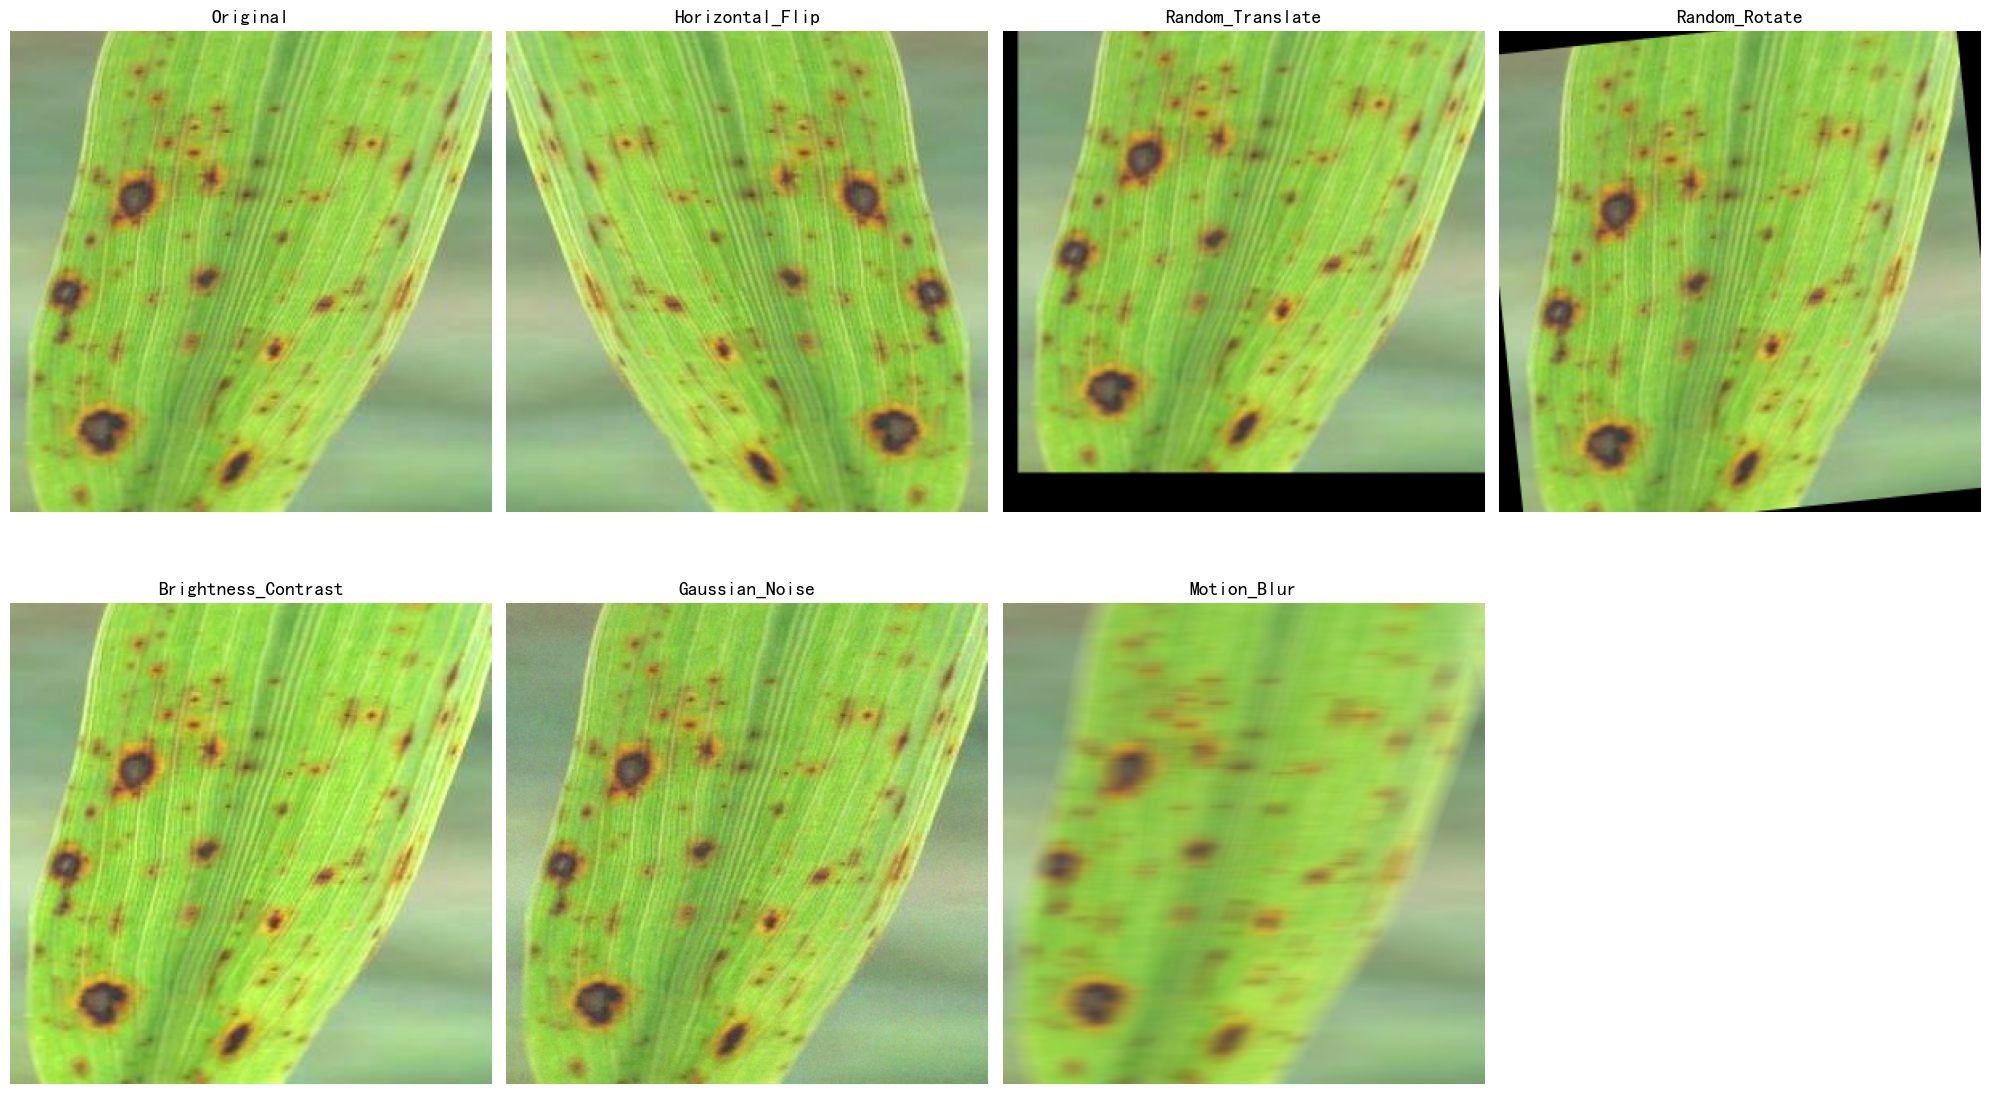

✅ 增强完成！图像已按增强方式命名并保存至: f:\rice leaf disease\yolov13-main\aug_preview


In [3]:
# --- 运行增强并以增强方式命名保存 ---

# 1. 读取原图和标签
orig_img = cv_imread(IMAGE_PATH)
orig_labels = load_labels(LABEL_PATH)

if orig_img is None:
    print("错误：无法读取图像，请检查 IMAGE_PATH")
else:
    # 2. 定义增强任务字典 { "显示名称": 执行函数 }
    # 这里的 Key 将直接作为保存的文件名和图片标题
    aug_tasks = {
        "Original": lambda i, l: (i, l),
        "Horizontal_Flip": flip_horiz,
        "Random_Translate": translate,
        "Random_Rotate": rotate,
        "Brightness_Contrast": lambda i, l: (brightness_contrast(i), l),
        "Gaussian_Noise": lambda i, l: (add_noise(i), l),
        "Motion_Blur": lambda i, l: (blur(i), l)
    }

    # 3. 设置绘图布局
    plt.figure(figsize=(20, 12))
    
    # 遍历任务并处理
    for idx, (name, func) in enumerate(aug_tasks.items()):
        # 执行增强逻辑
        aug_img, _ = func(orig_img.copy(), orig_labels.copy())
        
        # 保存图像：文件名直接使用增强方式名称
        save_path = os.path.join(OUTPUT_DIR, f"{name}.jpg")
        cv2.imwrite(save_path, aug_img)
        
        # 用于 Notebook 显示：BGR 转 RGB
        show_img = cv2.cvtColor(aug_img, cv2.COLOR_BGR2RGB)
        
        # 绘制子图
        plt.subplot(2, 4, idx + 1)
        plt.imshow(show_img)
        plt.title(name, fontsize=14, fontweight='bold')
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

    print(f"✅ 增强完成！图像已按增强方式命名并保存至: {os.path.abspath(OUTPUT_DIR)}")

计算一个类有多少个数据集

In [9]:
import os
import random
from collections import Counter

# ================= 配置区域 =================
LABEL_PATH = r'F:\rice leaf disease\datasets\val\labels'
# ===========================================

def count_random_label_per_file(folder_path):
    class_counts = Counter()
    file_count = 0

    if not os.path.exists(folder_path):
        print(f"错误：路径不存在 -> {folder_path}")
        return

    txt_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.txt')]
    
    for file_name in txt_files:
        file_path = os.path.join(folder_path, file_name)
        
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                lines = [line.strip() for line in f.readlines() if line.strip()]
            
            if lines:
                file_count += 1
                # --- 核心修改：从当前文件的所有标签行中随机选一行 ---
                target_line = random.choice(lines)
                
                parts = target_line.split()
                if parts:
                    class_id = parts[0]
                    class_counts[class_id] += 1
        except Exception as e:
            print(f"读取文件 {file_name} 时出错: {e}")

    print("-" * 30)
    print(f"随机抽样统计完成！")
    print(f"有效图片（含标签）总数: {file_count}")
    print("注：每张图片仅随机计入了一个标签目标")
    print("-" * 30)
    
    if not class_counts:
        print("未发现任何类别标签。")
    else:
        for cls_id in sorted(class_counts.keys(), key=int):
            print(f"类别 ID [{cls_id}]: {class_counts[cls_id]} 张图片包含此随机样本")
    print("-" * 30)

if __name__ == "__main__":
    count_random_label_per_file(LABEL_PATH)

------------------------------
随机抽样统计完成！
有效图片（含标签）总数: 290
注：每张图片仅随机计入了一个标签目标
------------------------------
类别 ID [0]: 68 张图片包含此随机样本
类别 ID [1]: 76 张图片包含此随机样本
类别 ID [2]: 146 张图片包含此随机样本
------------------------------
